# Image Example - Font Decomposition

# Import Libraries

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch

from TopNMF import *
from urllib.request import urlretrieve
device = 'cpu'

# Download font for Hangul generation
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    url = "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    urlretrieve(url, "NanumGothicCoding-Regular.ttf")
    print("Font Downloaded.")

# Generate & Preprocess Hangul Characters

In [3]:
def generate_hangul_images(image_size=(64, 64), font_size=48):
    """
    Generate images for the characters {가, 다, 라, 갸, 댜, 랴}
    using the NanumGothic font located in the same folder.
    Returns a NumPy array of grayscale images (no files written).
    """

    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    # Character set
    labels = ['가','다','라','갸','댜','랴']

    # Load the font
    font_path = os.path.join(base_dir, "NanumGothicCoding-Regular.ttf")
    font = ImageFont.truetype(font_path, font_size)

    W, H = image_size
    images = []

    for ch in labels:
        img = Image.new('L', (W, H), color=0)
        draw = ImageDraw.Draw(img)

        # Center text
        try:
            bbox = draw.textbbox((0, 0), ch, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except Exception:
            w, h = draw.textsize(ch, font=font)

        draw.text(((W - w) / 2, (H - h) / 2), ch, fill=255, font=font)
        images.append(np.array(img, dtype=np.uint8))

    images_array = np.stack(images, axis=0)
    return images_array, labels

# Generate images
images_array, labels = generate_hangul_images(font_size=48)
print(f"Generated {len(labels)} images, shape: {images_array.shape}")


Generated 6 images, shape: (6, 64, 64)


(6, 64, 64)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

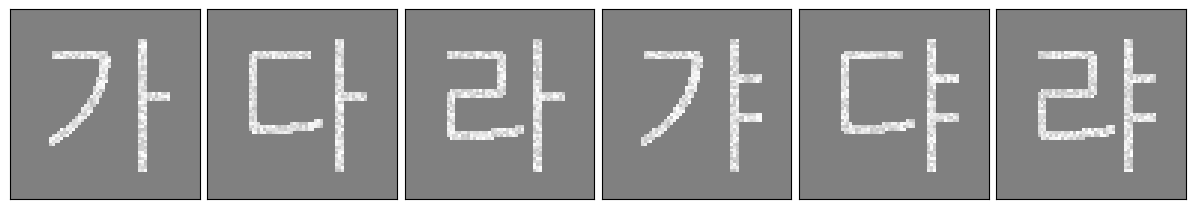

In [ ]:
X = np.astype(images_array > 127, np.float32)  # Binarize images
X *= np.random.uniform(low=0.5, high=1.0, size=X.shape)

n_components = 5 # number of basis vectors

n_samples = X.shape[0] # each row represents a sample
data_dims = X.shape[1:]
n_features = X[0].size
print(X.shape)

# display
n_row, n_col = 1, 6
plot_gallery(X,n_row=n_row, n_col = n_col)

# Run Top-NMF

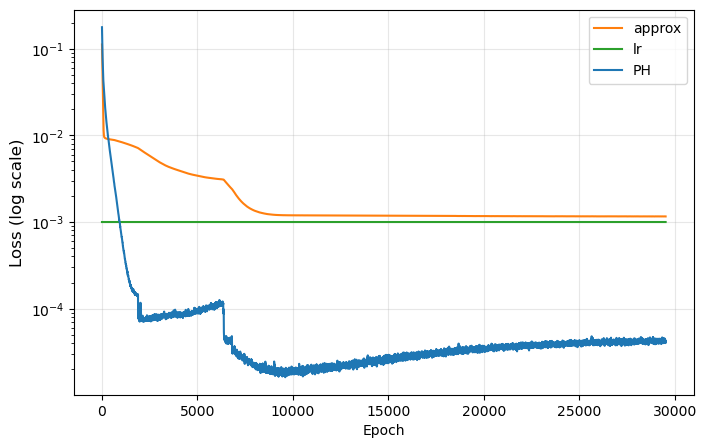

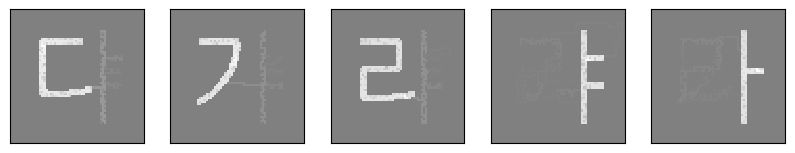

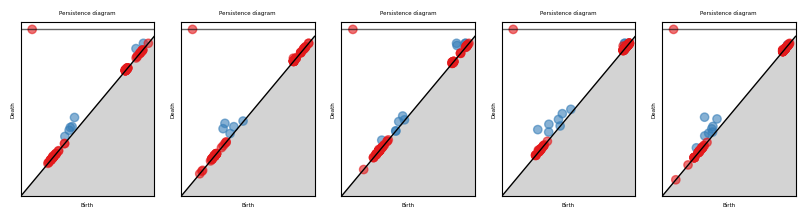

  0%|          | 0/30000 [00:00<?, ?it/s]

Final Loss: 0.0012


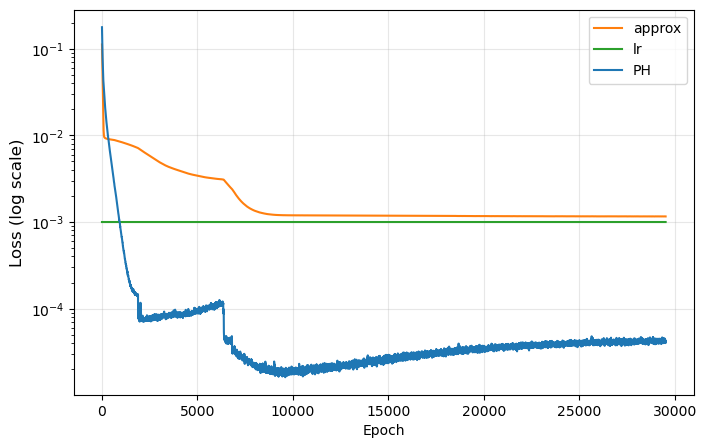

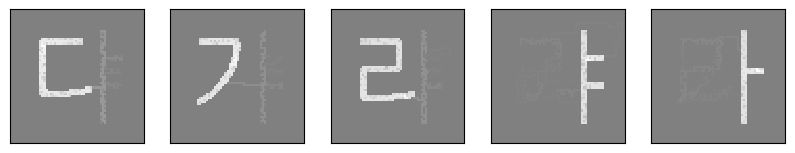

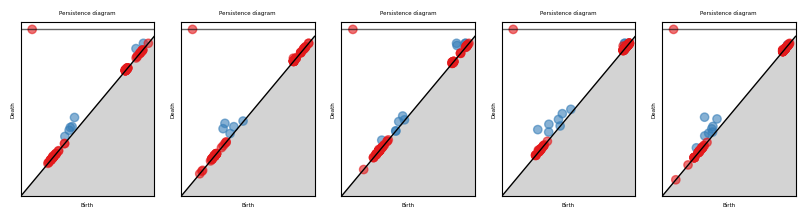

In [12]:
# Parameters
lr = 0.001 # learning rate
target_sparsity = None # set to None, if you are not using
PHmode = "V" # T or V construction
superlevel = True

## specify target persistence diagrams
target_diagrams = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]


n_iterations = 30000
lambda_top = 0.7
n_components = 5
PH_dims=[0]

# Create Cubical Complex
cubical_complex = CubicalComplex(superlevel=superlevel, dim=len(data_dims), mode=PHmode)

# Initialize Topological NMF model
model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=42,
    complex=cubical_complex,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims,
    use_embedding=False
)

# Fit the model
# Flatten data for NMF
X_flat = X.reshape(X.shape[0], -1)
model.fit(
    X_flat,
    n_iterations=n_iterations,
    lr=lr,
    PH_dims=PH_dims,
    lambda_top=lambda_top,
    weight_decay = 0.2,
    show_plots=['loss', 'basis', 'PH'],
    disp_interval=10,
    verbose=True,
    target_diagrams=target_diagrams,
    init_method = 'nndsvda',
    plot_grid = (1,5),
    superlevel=True,
    PHmode=PHmode
)

# Extract learned factors
W = model.W.detach().cpu().numpy()
V = model.V.detach().cpu().numpy()

print(f"Final Loss: {model.losses['approx'][-1]:.4f}")


# Compare Basis Vectors (Top-NMF vs standard NMF)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

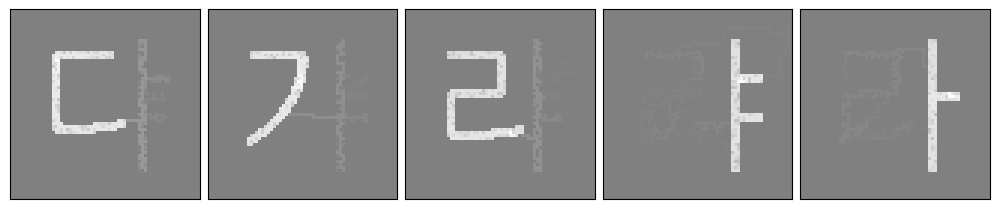

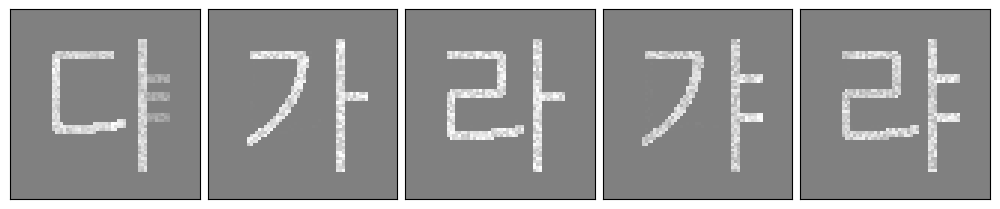

In [ ]:
from sklearn.decomposition import NMF

_ = plot_gallery(V.reshape(-1,*data_dims),title="",n_row=1, n_col = 5)

model = NMF(n_components=n_components, init='nndsvda', random_state=0)

W1 = model.fit_transform(X.reshape(n_samples, -1))
H1 = model.components_

plot_gallery(H1.reshape(-1, *data_dims), n_row=1, n_col=5)
